# House Price Prediction Project
**Intern:** Safiya Naguri
**Company:** XYlofy AI
**Assigned Date:** 17/05/2026
**Submission Date:** 21/05/2026

This notebook predicts house prices using regression models, based on property features such as area, bedrooms, bathrooms, and amenities.

## Task 1: Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('Housing.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (545, 13)


In [1]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**Target column:** `price`. **Feature columns:** area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus.

No missing values found — dataset is clean.

## Task 2: Data Cleaning

In [1]:
df_clean = df.copy()

# Check and remove duplicates
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

# Convert yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus (3 categories)
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head()

Duplicate rows: 0
Cleaned shape: (545, 14)


All yes/no text columns were converted into 1/0 numbers, and `furnishingstatus` (3 categories) was one-hot encoded, since models can only work with numbers.

## Task 3: Model Building

In [1]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), " Testing rows:", len(X_test))

Training rows: 436  Testing rows: 109


In [1]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
lr_r2 = r2_score(y_test, pred_lr)

print("Linear Regression -> MAE:", round(lr_mae), " RMSE:", round(lr_rmse), " R2:", round(lr_r2, 4))

Linear Regression -> MAE: 970043  RMSE: 1324507  R2: 0.6529


In [1]:
# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
rf_r2 = r2_score(y_test, pred_rf)

print("Random Forest -> MAE:", round(rf_mae), " RMSE:", round(rf_rmse), " R2:", round(rf_r2, 4))

Random Forest -> MAE: 1028648  RMSE: 1401052  R2: 0.6116


In [1]:
print("Linear Regression R2:", round(lr_r2, 4))
print("Random Forest R2:    ", round(rf_r2, 4))
better = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print("Better performing model:", better)

Linear Regression R2: 0.6529
Random Forest R2:     0.6116
Better performing model: Linear Regression


**Note:** Linear Regression slightly outperformed Random Forest here. With only 545 rows of data, the simpler model generalizes better, while Random Forest can overfit small patterns in a small dataset.

## Task 4: Visualization

### Chart 1: Distribution of House Prices

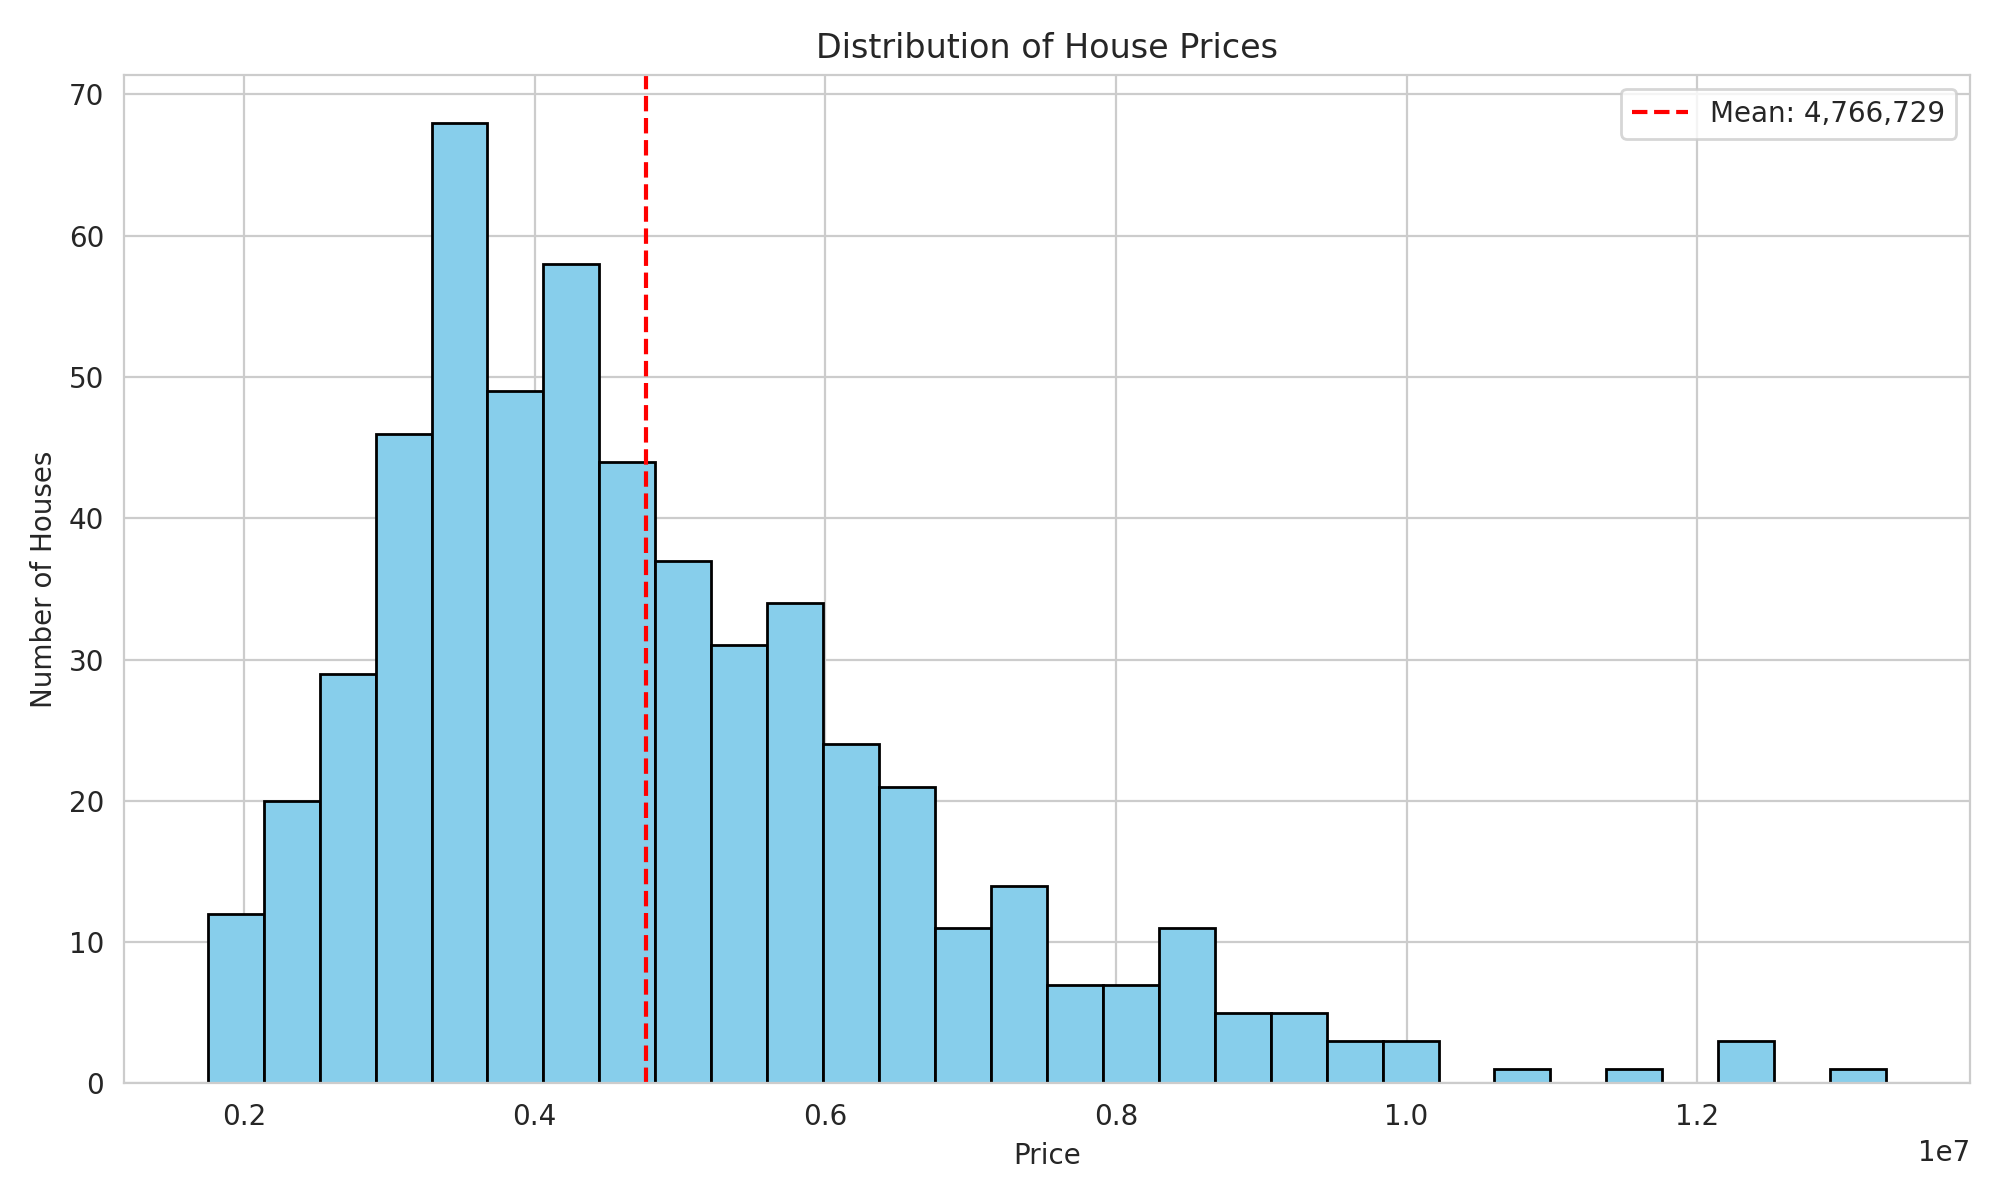

In [1]:
fig, ax = plt.subplots()
ax.hist(df_clean['price'], bins=30, color='skyblue', edgecolor='black')
ax.axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['price'].mean():,.0f}")
ax.set_xlabel('Price')
ax.set_ylabel('Number of Houses')
ax.set_title('Distribution of House Prices')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart_1_price_distribution.png', dpi=200)
plt.show()

### Chart 2: Correlation Heatmap

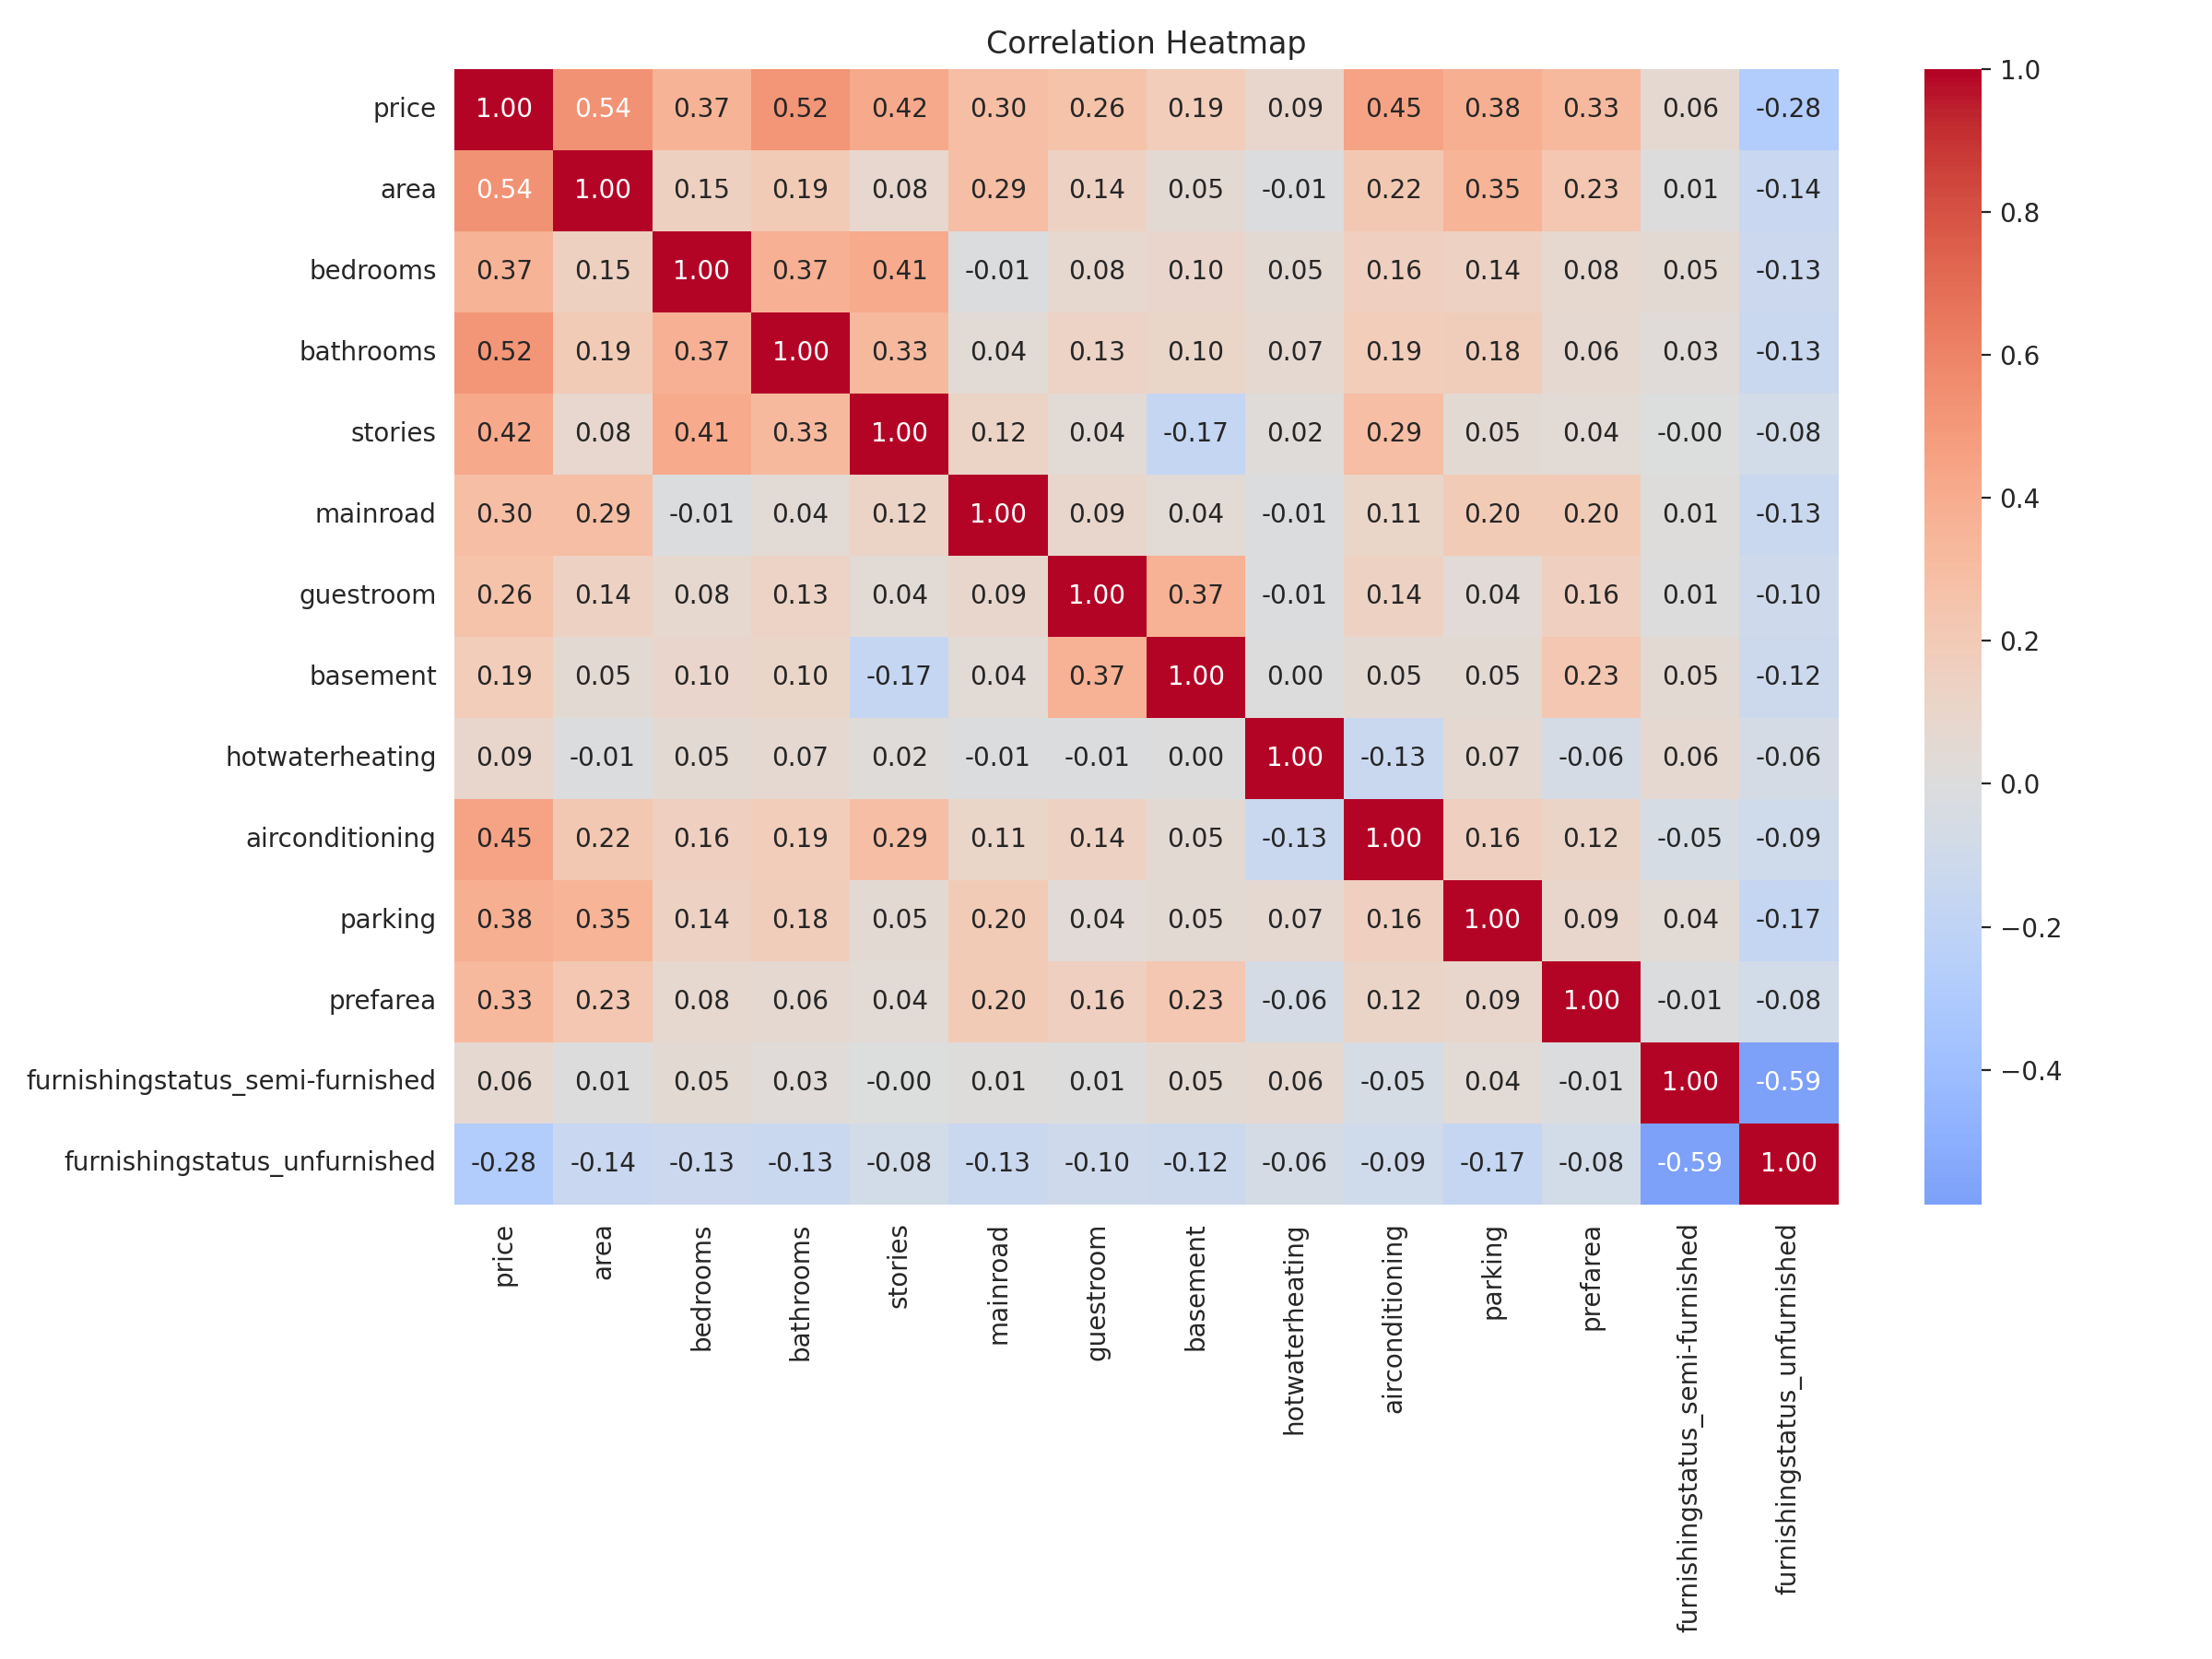

In [1]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart_2_correlation_heatmap.png', dpi=200)
plt.show()

### Chart 3: Actual vs Predicted Price

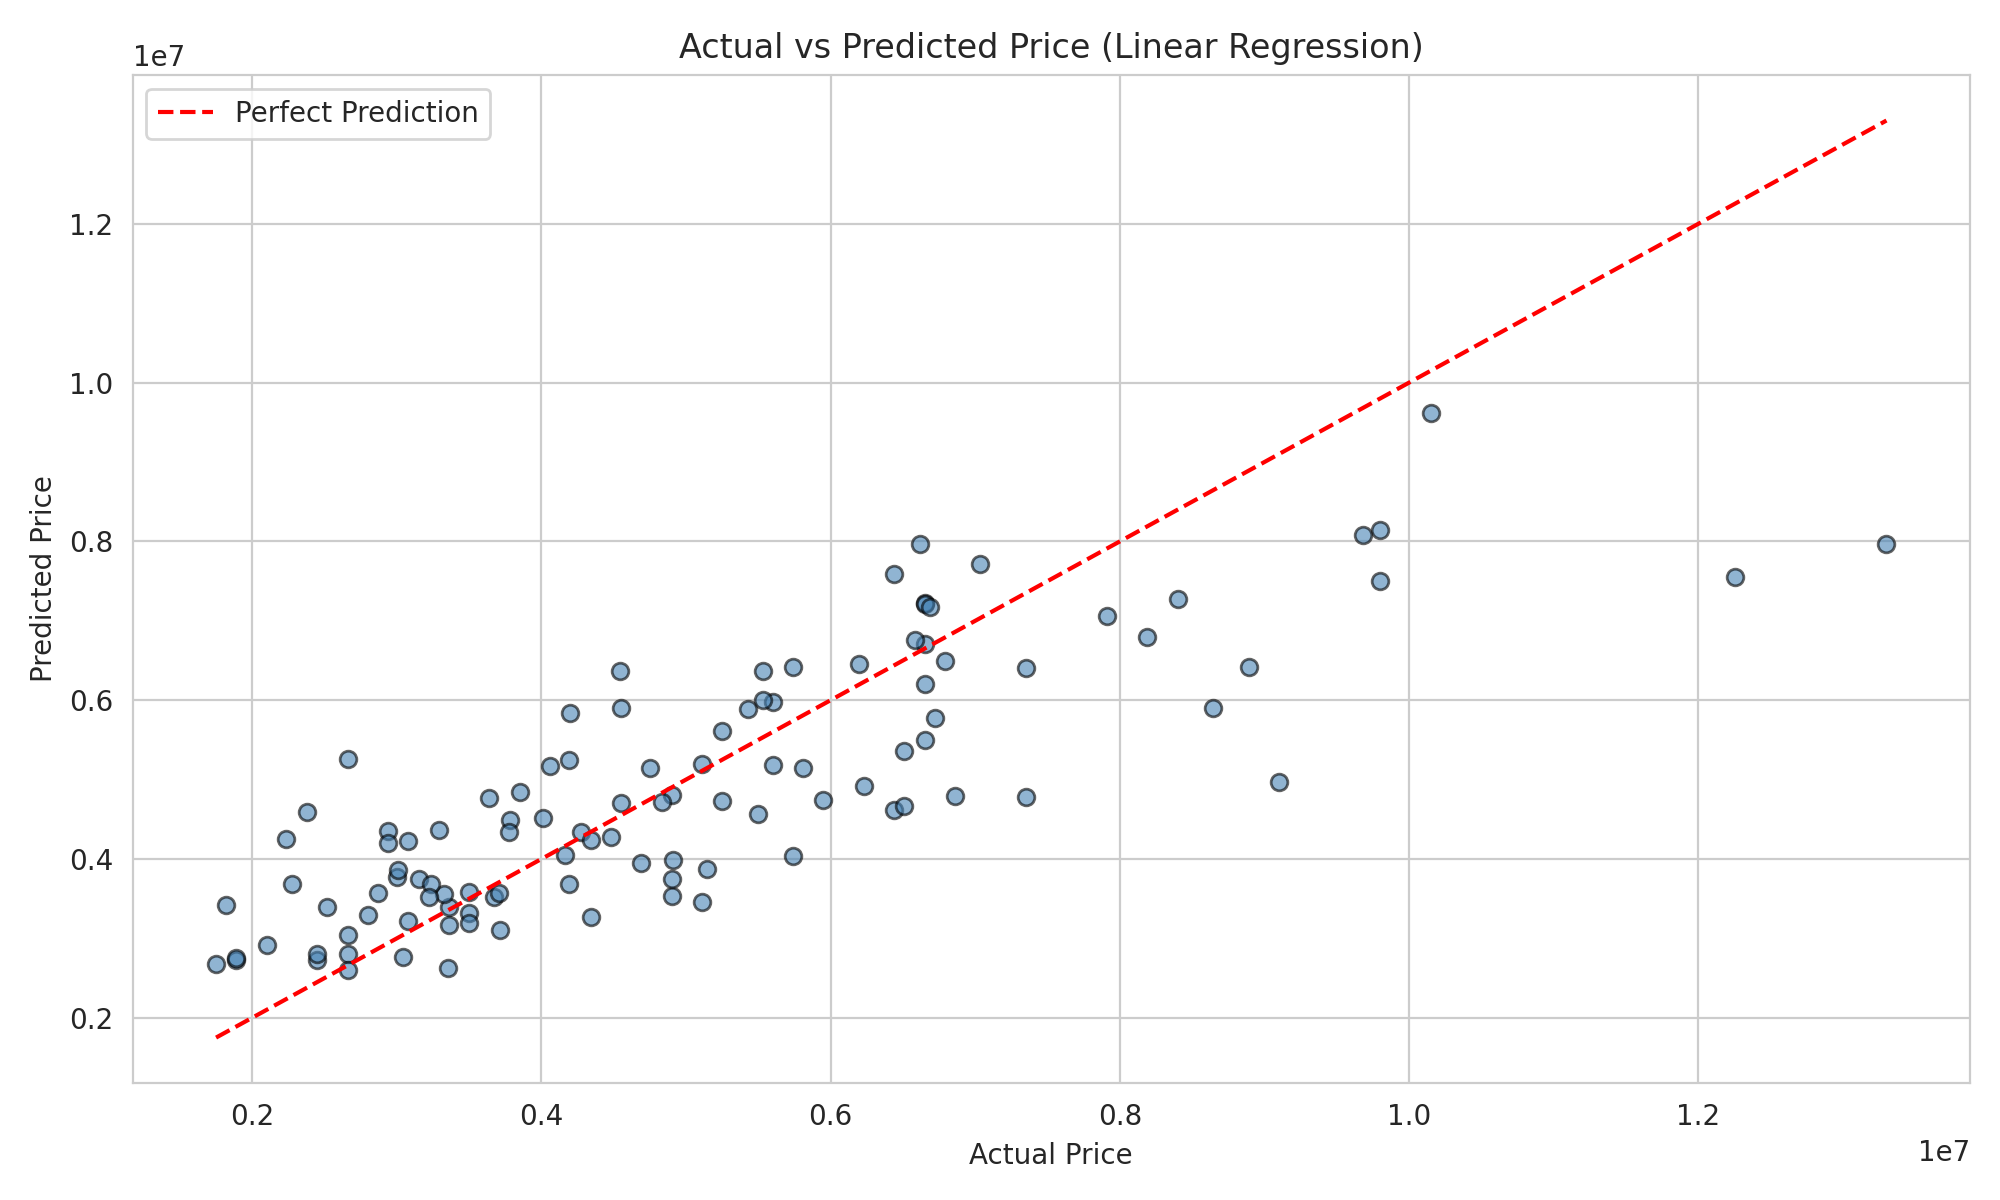

In [1]:
best_pred = pred_lr  # Linear Regression performed best
fig, ax = plt.subplots()
ax.scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolor='black')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims, lims, 'r--', label='Perfect Prediction')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Actual vs Predicted Price (Linear Regression)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart_3_actual_vs_predicted.png', dpi=200)
plt.show()

In [1]:
print(corr['price'].sort_values(ascending=False))

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


## Task 5: Insights & Summary

**Which features influence house price the most?**
Area, number of bathrooms, and air conditioning showed the strongest positive correlation with price (0.54, 0.52, and 0.45 respectively), followed by number of stories and parking spots. This matches real-world intuition: bigger homes with more bathrooms and modern amenities like AC naturally command higher prices.

**How accurate was your model (in plain terms)?**
The Linear Regression model performed best, explaining about 65% of the variation in house prices (R² = 0.65), with an average prediction error of roughly 970,000 per house. In plain terms, the model gets you reasonably close to the right price range, though it is not precise enough to be the final word on any single listing.

**What surprised you in the data?**
Random Forest, despite being a more "powerful" model on paper, actually performed slightly worse than simple Linear Regression here. With only 545 houses, the simpler model generalizes better, while the more complex model can overfit small patterns in a small dataset that don't hold up on new houses.

**One recommendation for a real estate business:**
This model could be used as a fair-pricing tool when listing new properties. Instead of relying purely on agent intuition, a seller or agent could plug in a new house's area, bathrooms, AC, and other features to get a baseline price estimate, then adjust from there based on local market conditions. This helps avoid listings that are significantly overpriced (sit unsold for months) or underpriced (lost revenue for the seller).

---
**Prepared by:** Safiya Naguri | **XYlofy AI Internship** | 2026